## Early exploration of tasseled cap coefficients


In [17]:
import datacube
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box, shape, MultiPolygon, MultiLineString
import matplotlib.pyplot as plt
import cartopy
from odc.geo.xr import assign_crs
from odc.geo.geom import Geometry
import warnings

import sys
#sys.path.insert(1, '/home/jovyan/git/dea-notebooks/Tools/')
sys.path.insert(1, '.../Tools')
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.dask import create_local_dask_cluster

warnings.filterwarnings("ignore")

In [2]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35791,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:43889,Total threads: 2
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/44575/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:37767,


## Analysis params



In [3]:
#region_code = 'x43y14' # se aus forests Alps.
# region_code = 'x39y09' # West tassie
# region_code = 'x33y26' # Central Aus with salt lakes
# region_code = 'x31y43' # Tropical NT
# region_code = 'x19y18' # Esperance crops and sand dunes
# region_code = 'x42y38' # Qld tropical forests
# region_code = 'x39y13' # Melbourne city and bay+crops
# region_code = 'x12y19' # Perth City
# region_code = 'x41y12' # Complex coastal in Vic.

region_codes = ['x43y14']

product = "ga_ls_tc_pc_cyear_3"

time="2015"
resolution = (-120, 120)
measurements = ["green_pc_50", "wet_pc_50", "bright_pc_50"]
dask_chunks = dict(x=1000, y=1000)

In [4]:
dc = datacube.Datacube(app="TCP_initial_exploration")

In [5]:
# measurements = dc.list_measurements()
# measurements.loc[product]

In [6]:
# set up dc query

query = {
    'time': time,
    'measurements': measurements,
    'resolution': resolution,
    'dask_chunks': dask_chunks,
}

In [7]:
# read tiles geojson and select 'golden tiles'

gdf = gpd.read_file('~/gdata1/data/albers_grids/ga_summary_grid_c3.geojson')

gdf = gdf[gdf['region_code'].isin(region_codes)]

In [8]:
#gdf.explore()

In [9]:
gdf.head()

,region_code,ix,iy,utc_offset,geometry
1238,x43y14,43,14,10,"POLYGON ((148.02451 -36.07520, 148.15892 -36.9..."


In [10]:
gdf.geometry

1238    POLYGON ((148.02451 -36.07520, 148.15892 -36.9...
Name: geometry, dtype: geometry

In [20]:
polygon = gdf.geometry.iloc[0] 

geom = Geometry(geom=polygon, crs=gdf.crs)
query.update({'geopolygon': geom})


In [21]:
# load data
ds = dc.load(
    product = product,
    **query
)

In [22]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:       (time: 1, y: 801, x: 801)
Coordinates:
  * time          (time) datetime64[ns] 8B 2015-07-02T11:59:59.999999
  * y             (y) float64 6kB -4.032e+06 -4.032e+06 ... -4.128e+06
  * x             (x) float64 6kB 1.44e+06 1.44e+06 ... 1.536e+06 1.536e+06
    spatial_ref   int32 4B 3577
Data variables:
    green_pc_50   (time, y, x) int16 1MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
    wet_pc_50     (time, y, x) int16 1MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
    bright_pc_50  (time, y, x) int16 1MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [23]:
ds.wet_pc_50

<xarray.DataArray 'wet_pc_50' (time: 1, y: 801, x: 801)> Size: 1MB
dask.array<dc_load_wet_pc_50, shape=(1, 801, 801), dtype=int16, chunksize=(1, 801, 801), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 8B 2015-07-02T11:59:59.999999
  * y            (y) float64 6kB -4.032e+06 -4.032e+06 ... -4.128e+06 -4.128e+06
  * x            (x) float64 6kB 1.44e+06 1.44e+06 ... 1.536e+06 1.536e+06
    spatial_ref  int32 4B 3577
Attributes:
    units:         percent
    nodata:        -9999
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

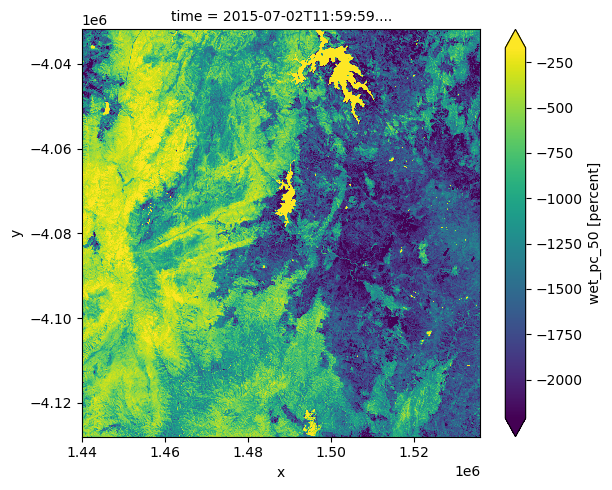

In [24]:
ds.wet_pc_50.plot(col='time', robust=True, size=5)